In [1]:
# 통계 기반 영화 추천 (학습없음 => 머신러닝 적용 X)

In [3]:
# 영화 데이터를 가져옴(csv 파일은 git에 업로드 안함)

import pandas as pd

df1 = pd.read_csv('tmdb_5000_credits.csv')
df2 = pd.read_csv('tmdb_5000_movies.csv')

In [ ]:

df1.columns

Index(['movie_id', 'title', 'cast', 'crew'], dtype='object')

In [7]:
df2.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')

In [9]:
# df1과 df2를 합치려면 합칠 수 있는 공통 열이름이 필요
# df1의 movie_id를 id로 변경해서 합치려고 함
df1.columns = ['id', 'title', 'cast', 'crew']
df1.columns

Index(['id', 'title', 'cast', 'crew'], dtype='object')

In [10]:
# df1 title에 결측치 개수 확인
print(f'df1 title의 결측치 수 : {df1['title'].isnull().any()}')
# df2 title에 결측치 개수 확인
print(f'df2 title의 결측치 수 : {df2['title'].isnull().any()}')

df1 title의 결측치 수 : False
df2 title의 결측치 수 : False


In [11]:
# df1 title 과 df2 title이 겹치는지 확인
print(f'df1 title과 df2 title이 일치합니까? : {df1['title'].equals(df2['title'])}')

df1 title과 df2 title이 일치합니까? : True


In [ ]:
# df2 뒤에 df1을 이어붙여서 합침(df1의 title은 제외 : 중복)
df = df2.merge(df1[['id', 'cast', 'crew']], on='id')
df.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [13]:
# C : 평균 평점
df2 = df2.merge(df1[['id', 'cast', 'crew']], on='id')
C= df2['vote_average'].mean()
C

np.float64(6.092171559442016)

In [14]:
# m : 투표수 상위 10%에 해당하는 값
m= df2['vote_count'].quantile(0.9)
m

np.float64(1838.4000000000015)

In [15]:
print(f'투표수 기준 상위 10% 제외하기전 전체 수{df2.shape}')

투표수 기준 상위 10% 제외하기전 전체 수(4803, 22)


In [18]:
# 투표수가 상위 10%보다 크거나 같은 데이터들만 뽑음
q_movies = df2.copy().loc[df2['vote_count'] >= m]
q_movies = q_movies.sort_values(by='vote_count', ascending=True)
print(f'투표수 기준 상위 10% 제외하기전 전체 수{q_movies.shape}')
print(q_movies[['id', 'vote_count']].head(3))

투표수 기준 상위 10% 제외하기전 전체 수(481, 22)
          id  vote_count
2585   12162        1840
195   181533        1851
2454    8467        1859


In [ ]:
# 가중치 함수 => 평균 평점만 가지고 추천을 하면 추천수는 적은데 점수가 높은 애들이 추천될 수 있음
# 투표수만 가지고 하면 평점이 낮은데 투표수가 높은 영화가 추천될 수 있음
# 위 두 상황을 해결하기 위해 새로운 가중치를 적용해서 영화를 추천
def weighted_rating(x, m=m, C=C):
	v = x['vote_count']
	r = x['vote_average']
	return (v/(v+m)*r)+(m/(m+v)*C)

In [23]:
# 영화 정보에 score는 열을 추가
# weighted_rating으로 계산된 값을 적용
# apply(함수) : 값을 적용할때 함수를 가져와서 이용
q_movies['score'] = q_movies.apply(weighted_rating, axis=1)

In [24]:
# score를 기준으로 내림차순 한 후 상위 10개를 추천(추천 영화)
q_movies = q_movies.sort_values(by='score', ascending=False)
q_movies[['title','vote_count','vote_average','score']].head(10)

,title,vote_count,vote_average,score
1881,The Shawshank Redemption,8205,8.5,8.059258
662,Fight Club,9413,8.3,7.939256
65,The Dark Knight,12002,8.2,7.920020
3232,Pulp Fiction,8428,8.3,7.904645
96,Inception,13752,8.1,7.863239
3337,The Godfather,5893,8.4,7.851236
95,Interstellar,10867,8.1,7.809479
809,Forrest Gump,7927,8.2,7.803188
329,The Lord of the Rings: The Return of the King,8064,8.1,7.727243
1990,The Empire Strikes Back,5879,8.2,7.697884


Text(0.5, 1.0, 'Popular Movies')

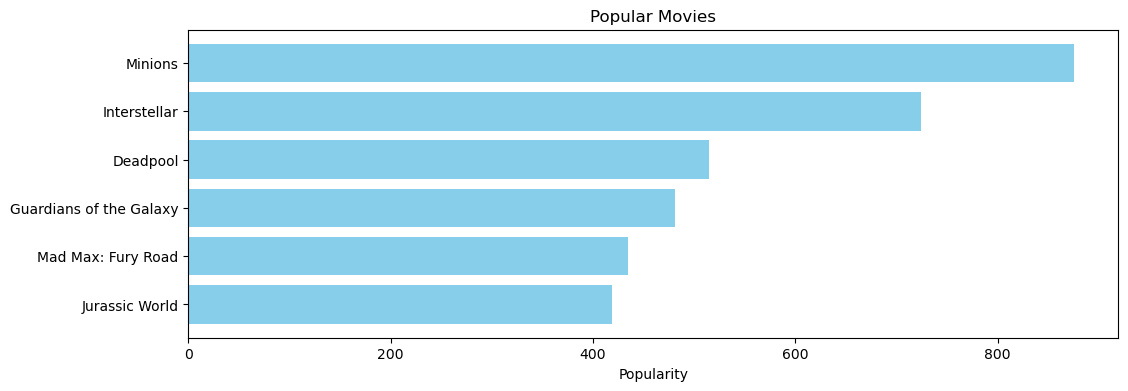

In [25]:
# popularity기반 영화 추천

pop= df2.sort_values('popularity', ascending=False)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))

plt.barh(pop['title'].head(6),pop['popularity'].head(6), align='center',
        color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel("Popularity")
plt.title("Popular Movies")